# C03 — Partial Fourier Imaging
### Computational MRI · Module 2 · Day 16
*"k-space is redundant — so why measure all of it?"*

This notebook turns CMRI Lecture 3 into runnable code. By the end you will have built, from scratch:

1. A demonstration that k-space has **Hermitian symmetry** for real-valued objects
2. A demonstration of **why that symmetry breaks** once the object has phase
3. Three partial-Fourier reconstructions: **zero-filling**, the **Margosian / homodyne** method, and **POCS**
4. The **SNR cost** of acquiring less data

Run it cell-by-cell. Then break it: change `PF`, change the phase, change the number of POCS iterations.

## 0 · Setup

Two conventions we use everywhere:

- **Phase-encode (PE) direction = rows (axis 0).** Partial Fourier under-samples *this* axis, because skipping PE lines is what actually saves scan time. Readout is essentially free.
- **Centered FFT.** `fft2c` puts k=0 in the middle of the array, which makes the symmetry and the sampling masks easy to reason about.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize

plt.rcParams['image.cmap'] = 'gray'
plt.rcParams['figure.dpi'] = 110

# ---- centered 2D FFT pair ----
def fft2c(x):  return np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(x)))
def ifft2c(X): return np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(X)))

def ksp_log(S):           # log-magnitude for displaying k-space
    return np.log(np.abs(S) + 1e-3)

N = 256
CTR = N // 2

# A synthetic "brain": Shepp-Logan phantom as the magnitude
magnitude = resize(shepp_logan_phantom(), (N, N), anti_aliasing=True)
print("phantom:", magnitude.shape, "range", magnitude.min(), "->", round(magnitude.max(), 3))

phantom: (256, 256) range 0.0 -> 1.0


## 1 · The motivation: scan time lives in k-space

Each **phase-encode line** of k-space costs one TR of scan time. A full 256-line acquisition that takes 10 minutes drops to ~5 minutes if we only acquire half the lines. Everything in this lecture is about *getting a full-resolution image back from a half-filled k-space*.

Below: the phantom, its full k-space, and what a half-sampled k-space looks like (the red rows are the ones we'd skip).

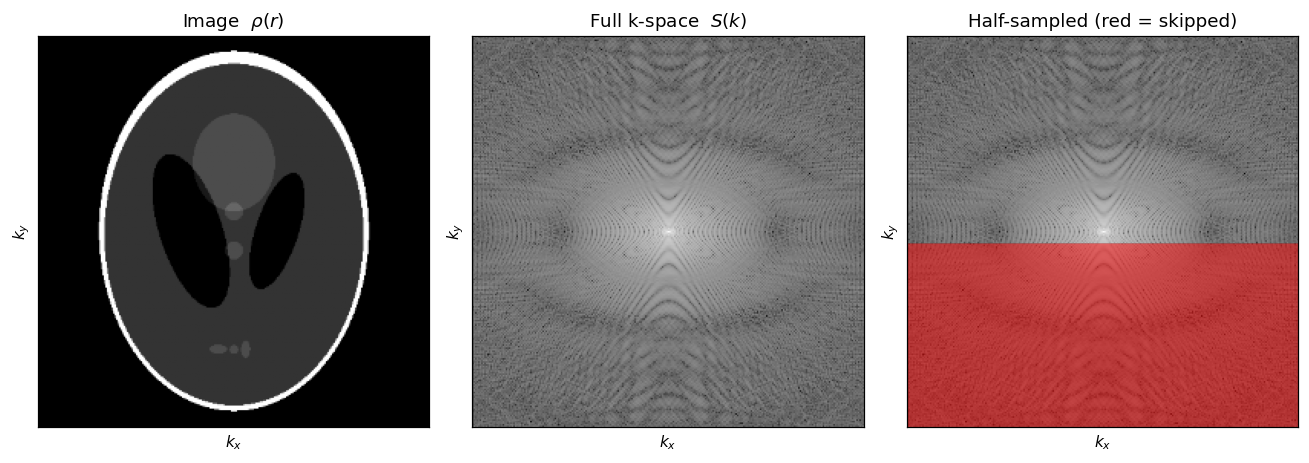

In [2]:
S_full = fft2c(magnitude)

# A "skip every other-ish line" cartoon just to visualize what undersampling means
mask_demo = np.ones((N, N))
mask_demo[CTR+8:, :] = 0.0     # drop the top portion of PE lines

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(magnitude);                 ax[0].set_title("Image  $\\rho(r)$")
ax[1].imshow(ksp_log(S_full));           ax[1].set_title("Full k-space  $S(k)$")
overlay = ksp_log(S_full).copy()
ax[2].imshow(overlay)
ax[2].imshow(np.ma.masked_where(mask_demo==1, np.ones((N,N))),
             cmap='autumn', alpha=0.5)
ax[2].set_title("Half-sampled (red = skipped)")
for a in ax: a.set_xlabel("$k_x$"); a.set_ylabel("$k_y$"); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 2 · Hermitian symmetry — the free lunch

If the object $\rho(r)$ is **real-valued**, its Fourier transform obeys

$$S(-k) = S^{*}(k) \qquad\text{(Hermitian / conjugate symmetry)}$$

So the bottom half of k-space is just the complex conjugate of the (mirrored) top half. **In theory we only need to measure half.**

Let's verify it numerically. One subtlety for an *even-sized* array: the negative-frequency partner of index $a$ lives at index $(N-a)\bmod N$, **not** at $N-1-a$. Getting this off-by-one right matters.

In [3]:
def neg_k(S):
    """Return S(-k): the value at the conjugate-symmetric partner of every sample.
    Implements index a -> (N - a) mod N via a flip + roll-by-1 (correct for even N)."""
    return np.roll(np.roll(S[::-1, ::-1], 1, axis=0), 1, axis=1)

# work on the *unshifted* FFT so the index arithmetic above is exact
def relerr(S): return np.linalg.norm(S - np.conj(neg_k(S))) / np.linalg.norm(S)

S_real  = np.fft.fft2(magnitude)                       # real object
yy, xx  = np.mgrid[-1:1:N*1j, -1:1:N*1j]
S_phase = np.fft.fft2(magnitude * np.exp(1j*(1.2*xx + 0.8*yy)))   # add smooth phase

print(f"Real-valued object : ||S - conj(S(-k))|| / ||S|| = {relerr(S_real):.2e}")
print(f"Object with phase  : ||S - conj(S(-k))|| / ||S|| = {relerr(S_phase):.2e}")

Real-valued object : ||S - conj(S(-k))|| / ||S|| = 2.68e-16
Object with phase  : ||S - conj(S(-k))|| / ||S|| = 1.23e+00


The relative error for the real object is at the level of floating-point noise (~1e-16): the symmetry is *exact*. As soon as the object carries phase, the symmetry is gone. That single fact is the whole reason partial Fourier needs a phase-correction step.

## 3 · Why the naive half-acquisition fails

Slides 6–7. The textbook fantasy: acquire the lower half of k-space, synthesize the upper half with $S(-k)=S^*(k)$, inverse-FFT, done. Let's try it on a real object and on an object with phase.

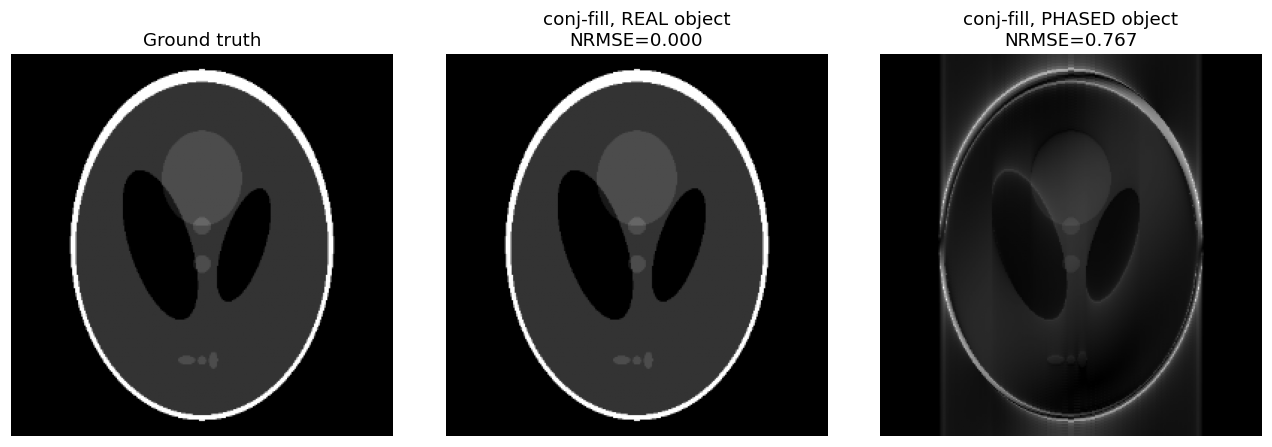

In [4]:
def hermitian_fill_recon(obj):
    """Acquire ~half of k-space, fill the rest using conjugate symmetry, reconstruct."""
    S = np.fft.fft2(obj)
    keep = np.zeros((N, N), bool); keep[:CTR+1, :] = True     # lower half + DC row
    Sf = np.zeros_like(S)
    Sf[keep] = S[keep]
    Sf[~keep] = np.conj(neg_k(S))[~keep]                      # synthesize the rest
    return np.abs(np.fft.ifft2(Sf))

gt = magnitude
rec_real  = hermitian_fill_recon(magnitude)
rec_phase = hermitian_fill_recon(magnitude * np.exp(1j*(2*xx + 1.5*yy)))
nrmse = lambda r: np.linalg.norm(r-gt)/np.linalg.norm(gt)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(gt);         ax[0].set_title("Ground truth")
ax[1].imshow(rec_real);   ax[1].set_title(f"conj-fill, REAL object\nNRMSE={nrmse(rec_real):.3f}")
ax[2].imshow(rec_phase);  ax[2].set_title(f"conj-fill, PHASED object\nNRMSE={nrmse(rec_phase):.3f}")
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

Perfect on the left (real object → symmetry is real), wrecked on the right. Real objects don't exist in MRI: $B_0$ inhomogeneity, chemical shift, flow, and motion all stamp a spatially-varying phase onto the image. **The fix (slide 8): acquire *slightly more* than half** — a small symmetric band around the k-space center — and use it to *estimate* the phase, then enforce it.

## 4 · The partial Fourier sampling layout

We acquire a contiguous block of PE lines from one edge through the center and a little beyond. Define the **partial Fourier fraction** `PF` (e.g. 9/16 = 0.5625):

- **Acquired**: rows $[0,\, N_{acq})$ where $N_{acq} = \mathrm{round}(PF\cdot N)$.
- **Symmetric band**: the central rows whose conjugate partner is *also* acquired → used for phase estimation.
- **Asymmetric region**: acquired rows with no acquired partner → these carry the high-resolution detail.

PF = 0.5625  ->  acquire 144/256 PE lines
symmetric band: rows [113, 143]  (width 31)


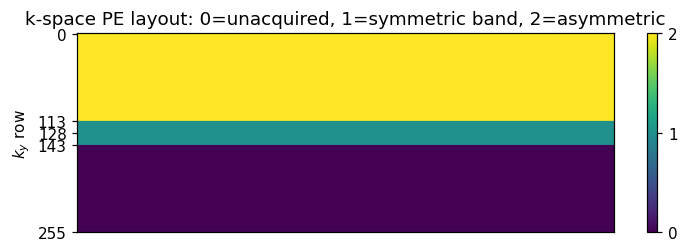

In [5]:
PF = 9/16                                   # try 5/8, 6/8, 0.75 ...
N_acq = int(round(PF * N))
mask = np.zeros((N, N), bool); mask[:N_acq, :] = True

half_w = N_acq - 1 - CTR                     # half-width of the symmetric band
SYM_LO, SYM_HI = CTR - half_w, CTR + half_w  # symmetric band row range

print(f"PF = {PF:.4f}  ->  acquire {N_acq}/{N} PE lines")
print(f"symmetric band: rows [{SYM_LO}, {SYM_HI}]  (width {SYM_HI-SYM_LO+1})")

region = np.zeros(N)
region[:SYM_LO] = 2          # asymmetric (high-freq detail, single-sided)
region[SYM_LO:SYM_HI+1] = 1  # symmetric band (both partners acquired)
# rows > N_acq-1 stay 0 (not acquired)
plt.figure(figsize=(7,2.4))
plt.imshow(np.tile(region[:,None],(1,N)), aspect='auto', cmap='viridis')
plt.yticks([0, SYM_LO, CTR, SYM_HI, N-1]); plt.xticks([])
plt.title("k-space PE layout: 0=unacquired, 1=symmetric band, 2=asymmetric"); plt.ylabel("$k_y$ row")
plt.colorbar(ticks=[0,1,2]); plt.tight_layout(); plt.show()

## 5 · Phase estimation

Take **only the symmetric central band**, taper it with a Hamming window (to suppress Gibbs ringing from the hard cutoff), inverse-FFT, and keep the phase. Because the band is symmetric and low-resolution, this gives a smooth, reliable estimate $\varphi(r)=\angle I_c(r)$ of the object's true phase — which is exactly the assumption we need: *real phase varies slowly*.

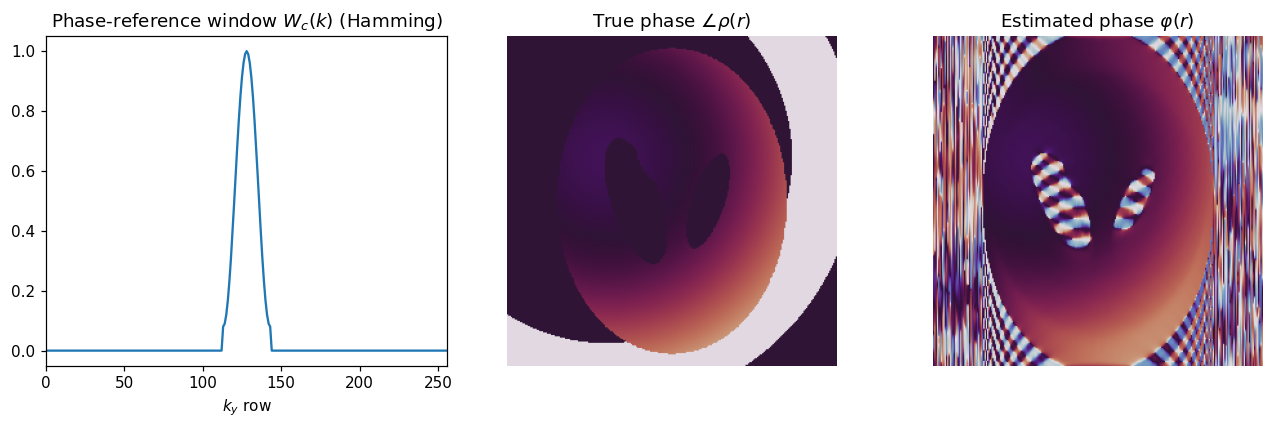

In [6]:
S0 = fft2c(magnitude * np.exp(1j*(1.2*xx + 0.8*yy + 1.5*(xx**2+yy**2)))) * mask  # our test data
obj_true = magnitude * np.exp(1j*(1.2*xx + 0.8*yy + 1.5*(xx**2+yy**2)))

# Hamming-tapered window over the symmetric band only
W_phase = np.zeros(N)
band = np.arange(SYM_LO, SYM_HI+1)
W_phase[band] = np.hamming(len(band))

I_ref = ifft2c(S0 * W_phase[:, None])
phi   = np.angle(I_ref)                      # estimated phase map

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].plot(W_phase); ax[0].set_title("Phase-reference window $W_c(k)$ (Hamming)")
ax[0].set_xlabel("$k_y$ row"); ax[0].set_xlim(0, N)
ax[1].imshow(np.angle(obj_true), cmap='twilight', vmin=-np.pi, vmax=np.pi); ax[1].set_title("True phase $\\angle\\rho(r)$"); ax[1].axis('off')
ax[2].imshow(phi, cmap='twilight', vmin=-np.pi, vmax=np.pi); ax[2].set_title("Estimated phase $\\varphi(r)$"); ax[2].axis('off')
plt.tight_layout(); plt.show()

The estimate (right) recovers the smooth true phase (middle) well inside the object. It's the handle every method below uses to "rotate away" the unknown phase so Hermitian symmetry can do its job.

## 6 · Baseline: zero-filled reconstruction

The do-nothing option: stick zeros where we didn't sample and inverse-FFT. It's the reference everything else has to beat. The missing high-frequency PE lines on one side cause blurring and a characteristic asymmetric ringing in the PE direction.

In [7]:
I_zerofill = np.abs(ifft2c(S0))
print("zero-filled NRMSE:", round(np.linalg.norm(I_zerofill-gt)/np.linalg.norm(gt), 4))

zero-filled NRMSE: 0.1919


## 7 · The Margosian / homodyne method (one-step)

The idea (slides 9–11):

1. Weight the acquired k-space with a **homodyne ramp** $W(k)$: value **2** in the single-sided (asymmetric) region — to stand in for the missing conjugate partner — ramping **2 → 0** across the symmetric band (so the doubly-sampled center isn't double-counted; it ends up weighted ~1 at $k=0$).
2. Inverse-FFT to get $I_0(r)=\mathcal{F}^{-1}\{S_0(k)\,W(k)\}$.
3. **Remove the estimated phase and take the real part:**
$$ I(r) = \mathrm{Re}\big\{ I_0(r)\, e^{-i\,\angle I_c(r)} \big\} $$

The phase rotation lines the true signal up with the real axis; whatever leaks into the imaginary axis was error, and `Re{}` discards it. One pass, no iteration.

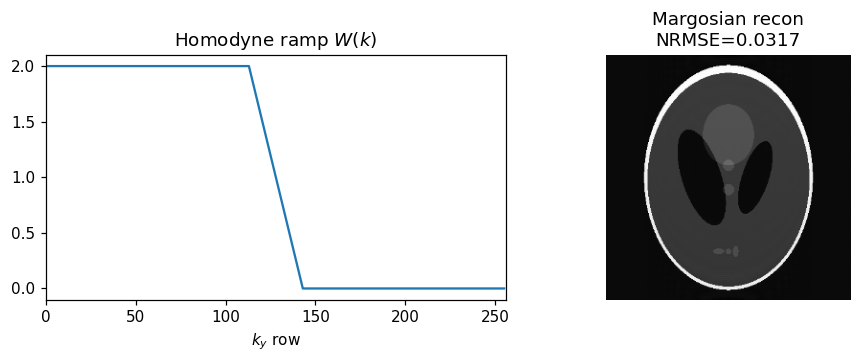

In [8]:
# homodyne ramp filter along the PE direction
W_hd = np.zeros(N)
W_hd[:SYM_LO] = 2.0                                        # asymmetric region
W_hd[SYM_LO:SYM_HI+1] = np.linspace(2.0, 0.0, SYM_HI-SYM_LO+1)  # ramp through center
# (rows above N_acq-1 remain 0)

I0 = ifft2c(S0 * W_hd[:, None])
I_margosian = np.real(I0 * np.exp(-1j*phi))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.4))
ax[0].plot(W_hd); ax[0].set_title("Homodyne ramp $W(k)$"); ax[0].set_xlabel("$k_y$ row"); ax[0].set_xlim(0,N)
ax[1].imshow(I_margosian); ax[1].axis('off')
ax[1].set_title(f"Margosian recon\nNRMSE={np.linalg.norm(I_margosian-gt)/np.linalg.norm(gt):.4f}")
plt.tight_layout(); plt.show()

## 8 · The POCS method (iterative)

Slides 14–17. Frame reconstruction as finding an image that satisfies **two convex constraints**:

- $\Omega_1$ — **Phase**: the image phase equals the estimated phase, $\angle I(r) = \varphi(r)$.
- $\Omega_2$ — **Data consistency**: where we *did* sample, the k-space must match what we measured, $S(k)=S_0(k)$.

**Projection Onto Convex Sets** alternates projecting onto each constraint until they agree:

```
init:  I_0 = F^{-1}(S_0)                       (zero-filled)
loop:  I  <- |I| * exp(i*phi)                  (impose estimated phase)
       S  <- F(I)
       S[sampled] <- S_0[sampled]              (impose measured data)
       I  <- F^{-1}(S)
```

It converges in a handful of iterations and, unlike Margosian, keeps *refining* the unsampled k-space instead of trusting a single weighting.

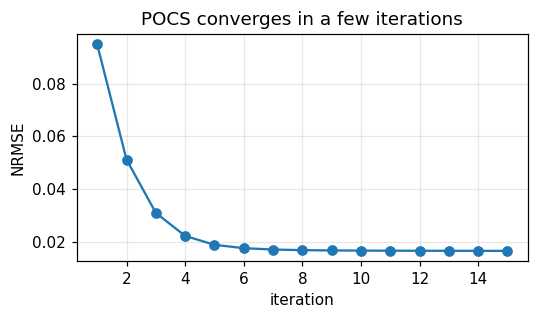

POCS final NRMSE: 0.0164


In [9]:
def pocs(S0, mask, phi, n_iter=15, track=False):
    I = ifft2c(S0)
    hist = []
    for _ in range(n_iter):
        I = np.abs(I) * np.exp(1j*phi)      # Omega_1: phase constraint
        S = fft2c(I)
        S[mask] = S0[mask]                  # Omega_2: data consistency
        I = ifft2c(S)
        if track: hist.append(np.linalg.norm(np.abs(I)-gt)/np.linalg.norm(gt))
    return (np.abs(I), hist) if track else np.abs(I)

I_pocs, hist = pocs(S0, mask, phi, n_iter=15, track=True)

plt.figure(figsize=(5,3))
plt.plot(range(1,len(hist)+1), hist, 'o-'); plt.xlabel("iteration"); plt.ylabel("NRMSE")
plt.title("POCS converges in a few iterations"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("POCS final NRMSE:", round(hist[-1], 4))

## 9 · The comparison plot (slide 18)

Original · Zero-filled · Margosian · POCS — full image, a zoomed crop, and the error map (×5) for each.

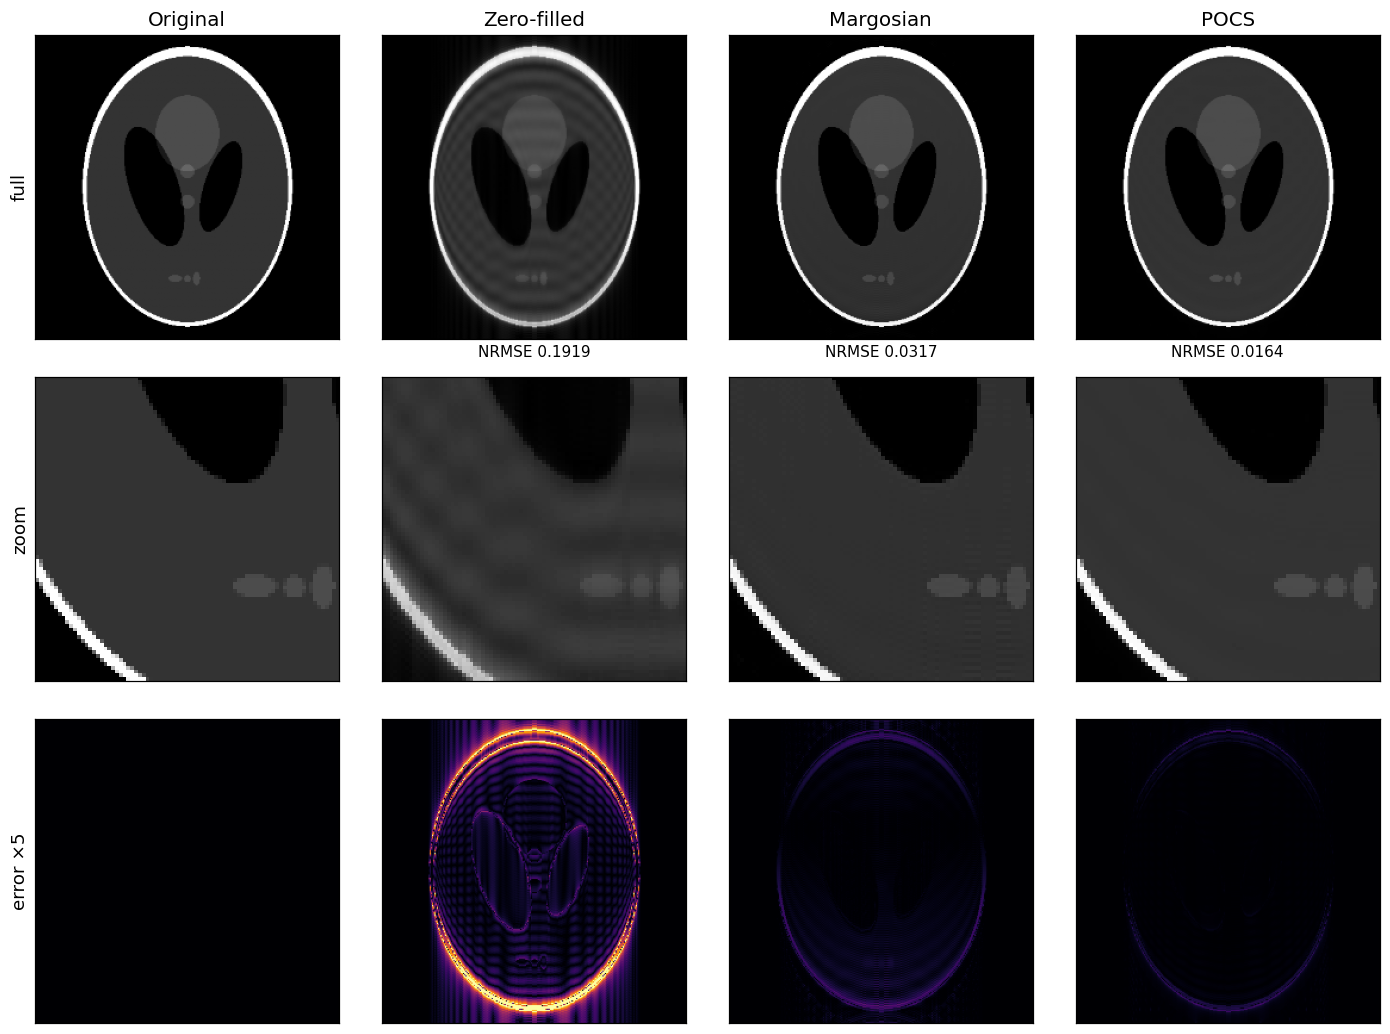

In [10]:
recons = {"Zero-filled": I_zerofill, "Margosian": I_margosian, "POCS": I_pocs}
cols = ["Original"] + list(recons)
imgs = [gt] + list(recons.values())

fig, ax = plt.subplots(3, 4, figsize=(13, 9.5))
crop = (slice(150,230), slice(60,140))
for j,(name,im) in enumerate(zip(cols, imgs)):
    ax[0,j].imshow(im, vmin=0, vmax=1); ax[0,j].set_title(name, fontsize=13)
    ax[1,j].imshow(im[crop], vmin=0, vmax=1)
    err = np.abs(im-gt)*5
    ax[2,j].imshow(err, vmin=0, vmax=1, cmap='inferno')
    if j>0:
        ax[0,j].set_xlabel(f"NRMSE {np.linalg.norm(im-gt)/np.linalg.norm(gt):.4f}")
for i,lab in enumerate(["full","zoom","error ×5"]): ax[i,0].set_ylabel(lab, fontsize=12)
for a in ax.ravel(): a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

## 10 · When does Margosian fail? (slide 18 annotation)

> *"In easy cases (no phase fluctuation) the result is the same. But in complicated data, Margosian fails, while POCS iterates to reach the optimal."*

Let's reproduce that directly: an **easy** object (slowly varying phase) vs a **hard** one (rapid, high-order phase). Watch the gap open up.

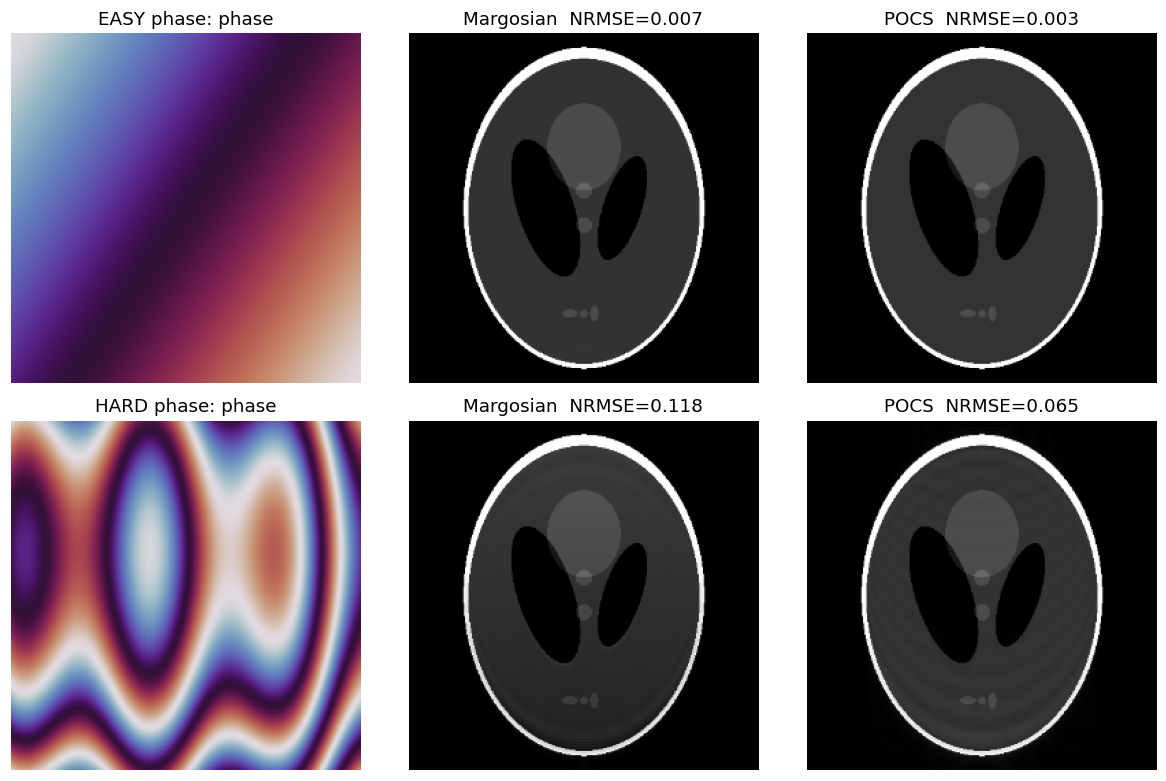

In [11]:
def run_both(phase_field, n_iter=15):
    obj = magnitude * np.exp(1j*phase_field)
    S0_ = fft2c(obj) * mask
    phi_ = np.angle(ifft2c(S0_ * W_phase[:, None]))
    marg = np.real(ifft2c(S0_ * W_hd[:, None]) * np.exp(-1j*phi_))
    pcs  = pocs(S0_, mask, phi_, n_iter)
    return marg, pcs

easy = 0.3*xx + 0.2*yy                                 # gentle
hard = 4*xx + 3*yy + 6*(xx**2+yy**2) + 2*np.sin(8*xx)  # rapid, high-order
labels = ["EASY phase", "HARD phase"]
fields = [easy, hard]

fig, ax = plt.subplots(2, 3, figsize=(11, 7.2))
for i,(lab,f) in enumerate(zip(labels, fields)):
    m, p = run_both(f)
    ax[i,0].imshow(((f+np.pi)%(2*np.pi))-np.pi, cmap='twilight'); ax[i,0].set_title(f"{lab}: phase")
    ax[i,1].imshow(m, vmin=0, vmax=1); ax[i,1].set_title(f"Margosian  NRMSE={np.linalg.norm(m-gt)/np.linalg.norm(gt):.3f}")
    ax[i,2].imshow(p, vmin=0, vmax=1); ax[i,2].set_title(f"POCS  NRMSE={np.linalg.norm(p-gt)/np.linalg.norm(gt):.3f}")
    for a in ax[i]: a.axis('off')
plt.tight_layout(); plt.show()

For the easy phase the two methods are basically tied — the one-step Margosian is plenty. For the hard phase, Margosian's single weighting can't undo the rapid phase and artifacts remain, while POCS keeps enforcing data consistency and lands closer to the truth. **This is the practical rule of thumb:** homodyne when phase is benign and you want speed; POCS when phase is ugly and you want robustness.

## 11 · The price you pay: SNR

Slide 19. Acquiring fewer samples means less signal averaging, so

$$ SNR \propto \frac{1}{\sqrt{R}}, \qquad R = \frac{N}{N_h} $$

where $N$ is the reconstructed size and $N_h$ the number of acquired samples. For $PF=9/16$, $R=16/9$ and the SNR factor is $\sqrt{9/16}=0.75$ — a 25% hit. The lecture's summary line: *"SNR loss close to $\sqrt 2$"* refers to the half-acquisition limit ($PF\to 1/2 \Rightarrow 1/\sqrt{2} \approx 0.707$).

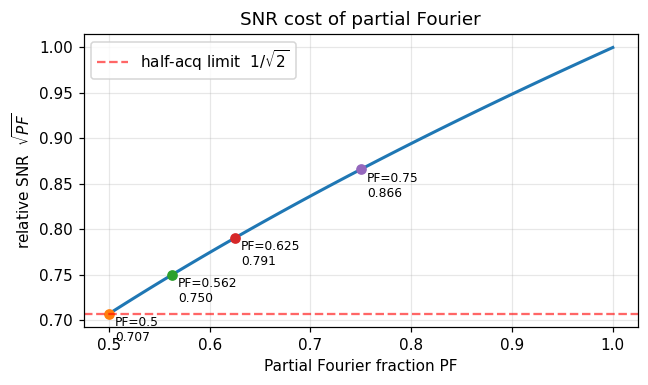

empirical SNR  full=1.93   PF=0.562 POCS=1.40   ratio=0.725  (theory 0.750)


In [12]:
pf_vals = np.linspace(0.5, 1.0, 60)
snr_factor = np.sqrt(pf_vals)            # 1/sqrt(R) = 1/sqrt(1/PF) = sqrt(PF)

plt.figure(figsize=(6,3.6))
plt.plot(pf_vals, snr_factor, lw=2)
for pf in [0.5, 9/16, 5/8, 0.75]:
    plt.plot(pf, np.sqrt(pf), 'o'); plt.annotate(f"PF={pf:.3g}\n{np.sqrt(pf):.3f}", (pf, np.sqrt(pf)),
              textcoords="offset points", xytext=(4,-18), fontsize=8)
plt.axhline(1/np.sqrt(2), ls='--', c='r', alpha=0.6, label='half-acq limit  $1/\\sqrt{2}$')
plt.xlabel("Partial Fourier fraction PF"); plt.ylabel("relative SNR  $\\sqrt{PF}$")
plt.title("SNR cost of partial Fourier"); plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# empirical check: add matched complex noise to full vs partial k-space
rng = np.random.default_rng(0)
sigma = 0.02 * np.abs(S_full).max()
noise = sigma*(rng.standard_normal((N,N)) + 1j*rng.standard_normal((N,N)))
full_noisy = np.abs(ifft2c(S_full + noise))
part_noisy = pocs((fft2c(magnitude)+noise)*mask, mask,
                  np.angle(ifft2c((fft2c(magnitude)+noise)*mask * W_phase[:,None])), 15)
roi = (slice(110,150), slice(110,150))   # near-uniform interior patch
snr = lambda im: im[roi].mean()/im[roi].std()
print(f"empirical SNR  full={snr(full_noisy):.2f}   PF={PF:.3g} POCS={snr(part_noisy):.2f}"
      f"   ratio={snr(part_noisy)/snr(full_noisy):.3f}  (theory {np.sqrt(PF):.3f})")

## 12 · Try it on real data (optional)

The whole pipeline above is acquisition-agnostic — swap the phantom for a real coil image and it just works. With an **IXI** or **fastMRI** slice:

```python
import nibabel as nib
vol = nib.load("IXI002-Guys-0828-T2.nii.gz").get_fdata()
sl  = vol[:, :, vol.shape[2]//2]
img = resize(sl/np.abs(sl).max(), (N, N))         # use as `magnitude`
# fastMRI gives true complex k-space + real phase — even better, skip the synthetic phase entirely
```

Real data carries genuine $B_0$ phase, so it's the honest test of Margosian-vs-POCS. Expect the gap from §10 to show up on its own.

## Self-test (no peeking)

1. State the Hermitian symmetry relation and the single property of the object it requires.
2. Real MRI objects are never truly real-valued. Name three physical sources of image phase.
3. Why do we acquire *slightly more* than half of k-space rather than exactly half?
4. What is the symmetric central band used for, and why is it windowed (e.g. Hamming) before use?
5. In the homodyne filter, why is the asymmetric region weighted by **2** while the center is weighted by **~1**?
6. Write the Margosian phase-corrected image equation and explain what `Re{·}` throws away.
7. Name the two convex constraints in POCS and the projection performed for each.
8. Give one regime where Margosian and POCS agree and one where they diverge. Why?
9. For $PF = 5/8$, compute the reduction factor $R$ and the relative SNR.
10. The summary says "SNR loss close to $\sqrt2$." Which limiting PF does that correspond to, and why is $\sqrt2$ the worst case for partial Fourier?

## Recap

- **Hermitian symmetry** makes half of k-space redundant — *for real objects*.
- Real objects have **phase**, so naive symmetry-fill fails; we acquire a small **symmetric band** to estimate that phase.
- **Margosian / homodyne**: one-step ramp-weight → phase-correct → `Re{}`. Fast, great when phase is smooth.
- **POCS**: alternate **phase** and **data-consistency** projections. Iterative, robust when phase is rough.
- **Cost**: $SNR \propto \sqrt{PF}$ — about 0.75 at 9/16, approaching $1/\sqrt{2}$ at the half-acquisition limit.

**Next (Day 17):** Module 2 review — take an image, transform to k-space, undersample, reconstruct three ways, and compare. You now have all three reconstructors in hand.